# Import Libraries

In [22]:
import pandas as pd
import numpy as np
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from textblob import TextBlob
import nltk
import matplotlib.pyplot as plt

# Download tokenizer
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\raina\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

# Load Dataset

In [15]:
# Load merged dataset
df = pd.read_csv("final_merged_all_models_updated.csv")

# Display basic info
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (783, 18)


,post_id,subreddit,title,selftext,top_comments,full_content,word_count,score,num_comments,created_utc,url,bert_extractive_summary,claude_abstractive_summary,gemini_abstractive_summary,gpt4o_abstractive_summary,llama_abstractive_summary,mistral_abstractive_summary,deepseek_abstractive_summary
0,1d7qc1r,india,Opposition deserves some appreciation...,Finally after a long time we saw the election ...,Stronger opposition means there will be health...,Opposition deserves some appreciation... Final...,308,3724,468,04-06-2024 06:16,https://www.reddit.com/r/india/comments/1d7qc1...,For this opposition deserves a bit of praise f...,The opposition mounted a strategic and impress...,The user commends the opposition for transform...,The opposition in the 2024 Indian Lok Sabha el...,The opposition deserves credit for a well-plan...,The author commends the opposition's strategic...,The opposition's strategic campaign in the 202...
1,1aigaax,worldnews,India involved in election interference in Can...,NaN,"On the Canada sub, every post on this topic wa...",India involved in election interference in Can...,68,3299,342,04-02-2024 05:21,https://www.reddit.com/r/worldnews/comments/1a...,India involved in election interference in Can...,The user expresses frustration about potential...,The user expresses suspicion that India is int...,The author expresses skepticism about India's ...,The author accuses India of election interfere...,The user expresses suspicion that India is med...,An intelligence report alleges India's involve...
2,1d88ox2,india,Celebration of a Political Defeat !!!,"Despite having vast financial power, full medi...",upcoming term will be tough job for him. Proba...,Celebration of a Political Defeat !!! Despite ...,172,3182,639,04-06-2024 21:27,https://www.reddit.com/r/india/comments/1d88ox...,This outcome is a clear celebration of their p...,The post expresses jubilation over the BJP's u...,The user expresses satisfaction with the elect...,The author expresses disbelief at the ruling p...,The BJP's failure to secure a majority despite...,The author expresses jubilance at the ruling p...,The author mocks the ruling party's failure to...
3,1cyoomv,worldnews,Prime Minister Narendra Modi convinced to be '...,NaN,"Just what we need, another leader with a god c...",Prime Minister Narendra Modi convinced to be '...,135,3112,792,23-05-2024 09:27,https://www.reddit.com/r/worldnews/comments/1c...,Prime Minister Narendra Modi convinced to be '...,The Reddit user critically comments on Prime M...,The user expresses concern over Prime Minister...,The author criticizes Prime Minister Modi for ...,The Prime Minister Narendra Modi's statement a...,The Reddit user expresses skepticism and amuse...,The post sarcastically criticizes Narendra Mod...
4,1d98ta7,india,Election results have revealed Modi followers ...,"Ever since the election results came out, ther...",I was very surprised about the result in Ayodh...,Election results have revealed Modi followers ...,328,2811,325,06-06-2024 03:30,https://www.reddit.com/r/india/comments/1d98ta...,Election results have revealed Modi followers ...,The post expresses deep frustration with Modi ...,The user expresses dismay at the post-election...,The recent election results have exposed the t...,Hardcore Modi supporters are unleashing a torr...,"""Post-election, hardcore Modi supporters have ...",The election results have exposed the deep-sea...


# Define Reference Column

In [16]:
reference_column = "bert_extractive_summary"

# Define Model Columns

In [17]:
model_columns = [
    "gpt4o_abstractive_summary",
    "gemini_abstractive_summary",
    "llama_abstractive_summary",
    "deepseek_abstractive_summary",
    "mistral_abstractive_summary",
    "claude_abstractive_summary"
]

# Initialize Metrics

In [18]:
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
smooth = SmoothingFunction().method1

results = {}

# Evaluation Loop (ROUGE + BLEU + Length + Sentiment)

In [19]:
for model in model_columns:
    
    rouge1_list = []
    rouge2_list = []
    rougeL_list = []
    bleu_list = []
    length_ratio_list = []
    sentiment_shift_list = []
    
    for i in range(len(df)):
        
        reference = str(df.loc[i, reference_column])
        hypothesis = str(df.loc[i, model])
        
        # ROUGE
        scores = scorer.score(reference, hypothesis)
        rouge1_list.append(scores['rouge1'].fmeasure)
        rouge2_list.append(scores['rouge2'].fmeasure)
        rougeL_list.append(scores['rougeL'].fmeasure)
        
        # BLEU with smoothing
        bleu = sentence_bleu(
            [reference.split()],
            hypothesis.split(),
            smoothing_function=smooth
        )
        bleu_list.append(bleu)
        
        # Length Ratio
        length_ratio = len(hypothesis.split()) / max(len(reference.split()), 1)
        length_ratio_list.append(length_ratio)
        
        # Sentiment Shift
        ref_sentiment = TextBlob(reference).sentiment.polarity
        hyp_sentiment = TextBlob(hypothesis).sentiment.polarity
        sentiment_shift = abs(ref_sentiment - hyp_sentiment)
        sentiment_shift_list.append(sentiment_shift)
    
    results[model] = {
        "ROUGE-1": np.mean(rouge1_list),
        "ROUGE-2": np.mean(rouge2_list),
        "ROUGE-L": np.mean(rougeL_list),
        "BLEU": np.mean(bleu_list),
        "Avg Length Ratio": np.mean(length_ratio_list),
        "Sentiment Shift": np.mean(sentiment_shift_list)
    }

# Convert Results to DataFrame

In [20]:
results_df = pd.DataFrame(results).T
results_df

,ROUGE-1,ROUGE-2,ROUGE-L,BLEU,Avg Length Ratio,Sentiment Shift
gpt4o_abstractive_summary,0.306856,0.074329,0.194718,0.020559,1.015915,0.159754
gemini_abstractive_summary,0.307273,0.075107,0.192757,0.017872,1.036108,0.157776
llama_abstractive_summary,0.304834,0.080936,0.191631,0.020926,0.895131,0.174949
deepseek_abstractive_summary,0.291086,0.069375,0.182392,0.016863,0.950763,0.167381
mistral_abstractive_summary,0.271722,0.065179,0.173340,0.013586,0.751084,0.174798
claude_abstractive_summary,0.263244,0.053241,0.159039,0.014168,1.038486,0.155572


# ROUGE Comparison Graph

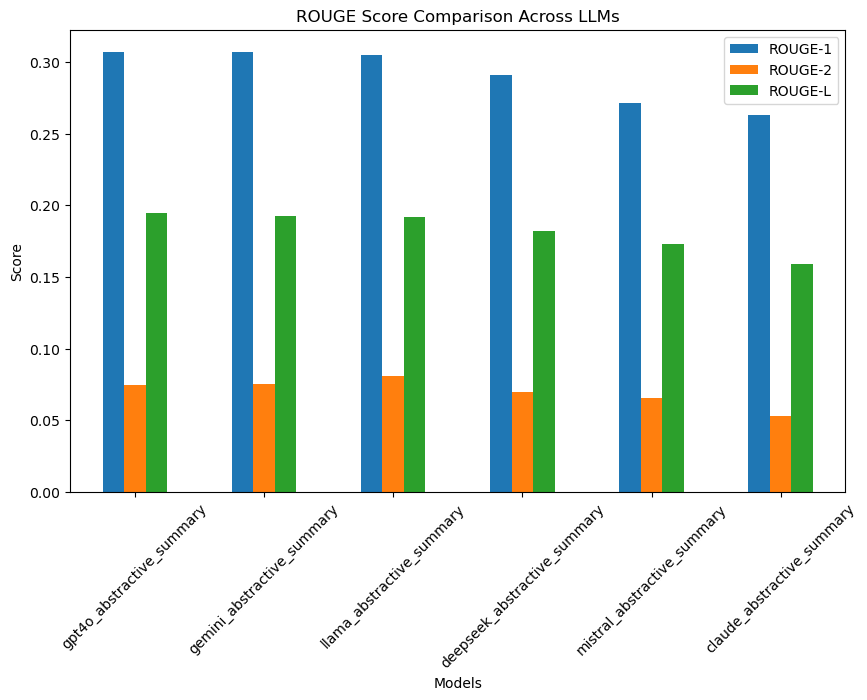

In [23]:
results_df[['ROUGE-1','ROUGE-2','ROUGE-L']].plot(kind='bar', figsize=(10,6))

plt.title("ROUGE Score Comparison Across LLMs")
plt.ylabel("Score")
plt.xlabel("Models")
plt.xticks(rotation=45)

plt.show()